# Reducing GPU Power Spikes While Preserving Throughput

A method-design notebook built on top of `arithmetic-square-wave-analysis.ipynb`.
The parent notebook *characterises* the GPU power-management loop (≈ 0.83 Hz
−3 dB bandwidth, ≈ 190 ms time constant, asymmetric slew with cooling slower
than heating). This notebook *uses* that characterisation to design and
simulate three methods of reducing peak power without losing useful work.

| Section | What it shows |
|---------|---------------|
| 4 · Spike taxonomy            | Peak/mean ratio, time-above-threshold, ramp rates across the sweep |
| 5 · Spectral attribution      | What fraction of power variance lives below the loop bandwidth |
| 6 · Per-device phase coherence| Are the four GPUs spiking in lockstep? (key for staggering) |
| 7 · **Method 1**: Phase-staggered duty cycling | Time-shift each GPU's hot phase by k·T/N |
| 8 · **Method 2**: Bandwidth-shaped pacing       | Drive faster than fc so the loop attenuates the swing |
| 9 · **Method 3**: Input shaping (pre-filter)    | Convolve workload schedule with the inverse loop response |
| 10 · Pareto frontier           | Peak reduction vs throughput retained, all three methods |
| 11 · Concrete recipe           | Numeric recommendation for deployment |

**Inputs:** the same 32-run square-wave sweep used in the parent notebook
(`rocm_smi::energy_count:device=*`).

**Throughput definition:** mean power *above the cold-phase floor* over the
run, integrated. This is the area under the workload-driven excursion of the
power signal — a hardware-agnostic proxy for delivered work.

## 1 · Setup

In [1]:
import os
import re
from glob import glob

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy import signal
from scipy.optimize import curve_fit, minimize_scalar
from scipy.stats import binned_statistic

from ampere import (
    Ensemble, Metric, MetricConfig, MetricType,
    connect, set_backend, ak,
)

set_backend('pandas')
connect(server="localhost", port=5555)

plt.rcParams.update({
    'figure.dpi':         110,
    'savefig.dpi':        140,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.titleweight':   'bold',
    'axes.titlepad':      10,
    'axes.labelsize':     11,
    'axes.titlesize':     12,
    'axes.grid':          True,
    'grid.alpha':         0.22,
    'grid.linestyle':     '--',
    'grid.linewidth':     0.7,
    'font.size':          11,
    'legend.frameon':     False,
    'legend.fontsize':    9,
})

TDP         = 560
GPU_DEVICES = (0, 2, 4, 6)
N_DEV       = len(GPU_DEVICES)
TDP_TOTAL   = TDP * N_DEV
SKIP_HEAD, SKIP_TAIL = 3.0, 1.0   # seconds of run head/tail to discard

    _         _                   _       
   / \   _ __| | _____  _   _  __| | __ _ 
  / _ \ | '__| |/ / _ \| | | |/ _` |/ _` |
 / ___ \| |  |   < (_) | |_| | (_| | (_| |
/_/   \_\_|  |_|\_\___/ \__,_|\__,_|\__,_|
                                          
Client Version: 2026.02.02+40.gec39a6ec8Pandas backend active — skipping Arkouda connection.


## 2 · Load traces and derive power metrics

In [2]:
TRACE_ROOT = "/Users/hom/Documents/ampere/examples/arithmetic-square-wave-04-29-26-13:50:09"
TRACES = sorted(
    glob(os.path.join(TRACE_ROOT, "cycles-*")),
    key=lambda s: int(s.rsplit('-', 1)[-1]),
)
for trace in TRACES:
    if not glob(os.path.join(trace, "*.csv")):
        os.system(f"cd {trace} && ~/otf2csv ./traces.otf2")

configs = {re.compile(r".*rocm.*energy.*"):
           MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6)}
ensemble = Ensemble.from_trace_paths(TRACES, {"Node0": ["Process"]}, configs)

cycle_counts = [int(t.rsplit('-', 1)[-1]) for t in TRACES]
N_RUNS = len(cycle_counts)
print(f"Loaded {N_RUNS} runs:  cycles ∈ [{min(cycle_counts)}, {max(cycle_counts)}]")

Loading Runs: 100%|██████████| 32/32 [00:00<00:00, 72.88it/s]

Loaded 32 runs:  cycles ∈ [1, 5040]


In [3]:
def differentiate_energy(energy_metric):
    t, e = energy_metric.times, energy_metric.values
    dt = t[1:] - t[:-1]
    de = e[1:] - e[:-1]
    p  = de / dt
    p  = ak.where((p < 0) | (dt <= 0), 0.0, p)
    return Metric("power", t[1:], p, MetricConfig(MetricType.INSTANTANEOUS))


def sum_power(*metrics):
    L      = min(len(m.times) for m in metrics)
    times  = min((m.times for m in metrics), key=len)
    values = np.sum([np.asarray(m.values)[:L] for m in metrics], axis=0)
    return Metric('combined_gpu_power', times, values,
                  MetricConfig(MetricType.INSTANTANEOUS))


for d in GPU_DEVICES:
    ensemble.add_derived_metric(
        f"A2rocm_smi:::inst_power:device={d}",
        differentiate_energy,
        f"A2rocm_smi:::energy_count:device={d}",
    )
ensemble.add_derived_metric(
    "A2rocm_smi:::combined_gpu_power",
    sum_power,
    *(f"A2rocm_smi:::inst_power:device={d}" for d in GPU_DEVICES),
)

Deriving metric 'A2rocm_smi:::inst_power:device=0'...
Deriving metric 'A2rocm_smi:::inst_power:device=2'...
Deriving metric 'A2rocm_smi:::inst_power:device=4'...
Deriving metric 'A2rocm_smi:::inst_power:device=6'...
Deriving metric 'A2rocm_smi:::combined_gpu_power'...


## 3 · Cache and shared helpers

In [4]:
def extract(metric):
    return np.asarray(metric.times), np.asarray(metric.values)


combined_power = []
device_power   = {d: [] for d in GPU_DEVICES}
for run in ensemble.runs:
    combined_power.append(extract(run.nodes[0].metrics["A2rocm_smi:::combined_gpu_power"]))
    for d in GPU_DEVICES:
        device_power[d].append(extract(run.nodes[0].metrics[f"A2rocm_smi:::inst_power:device={d}"]))


def f0_of(i):
    t, _ = combined_power[i]
    return cycle_counts[i] / (t[-1] - t[0])


def half_period_ms_of(i):
    t, _ = combined_power[i]
    return 1000.0 * (t[-1] - t[0]) / (2 * cycle_counts[i])


def steady(t, p, head=SKIP_HEAD, tail=SKIP_TAIL):
    m = (t >= t[0] + head) & (t <= t[-1] - tail)
    return t[m], p[m]


def resample_uniform(t, p, dt=0.001):
    tu = np.arange(t[0], t[-1], dt)
    return tu, np.interp(tu, t, p)


hp_ms   = np.array([half_period_ms_of(i) for i in range(N_RUNS)])
order   = np.argsort(hp_ms)
PALETTE = plt.cm.plasma(np.linspace(0.12, 0.88, N_RUNS))

In [5]:
# Re-fit the first-order LP model so this notebook is self-contained.
def amplitude_spectrum(t, p, dt=0.001):
    t, p = steady(np.asarray(t, float), np.asarray(p, float))
    if len(t) < 64:
        return np.array([]), np.array([])
    tu, pu = resample_uniform(t, p, dt)
    pd = signal.detrend(pu, type='linear')
    w  = signal.windows.hann(len(pd))
    spec = np.fft.rfft(pd * w)
    freq = np.fft.rfftfreq(len(pd), dt)
    mag  = (2.0 / w.sum()) * np.abs(spec)
    return freq, mag


def square_wave_amplitude(t, p):
    _, p = steady(t, p)
    if len(p) < 64:
        return 0.0
    return 0.5 * (np.percentile(p, 95) - np.percentile(p, 5))


def measured_at(freq, mag, f_target, half_window=2):
    idx = int(np.argmin(np.abs(freq - f_target)))
    lo, hi = max(0, idx - half_window), min(len(mag), idx + half_window + 1)
    return mag[lo:hi].max() if hi > lo else 0.0


tf_freq, tf_ratio = [], []
for i, (t, p) in enumerate(combined_power):
    fg, mg = amplitude_spectrum(t, p)
    A = square_wave_amplitude(t, p)
    if not len(fg) or A <= 0:
        continue
    f0 = f0_of(i)
    ideal = 4.0 * A / np.pi
    meas  = measured_at(fg, mg, f0)
    tf_freq.append(f0)
    tf_ratio.append(meas / ideal)

tf_freq, tf_ratio = np.array(tf_freq), np.array(tf_ratio)
def first_order_lp(f, fc): return 1.0 / np.sqrt(1.0 + (f / fc) ** 2)
popt, _ = curve_fit(first_order_lp, tf_freq, tf_ratio, p0=[1.0],
                    bounds=(0.01, 1000))
fc_fit  = float(popt[0])
tau_fit = 1.0 / (2 * np.pi * fc_fit)
print(f"Loop bandwidth fc = {fc_fit:.3f} Hz   |   τ = {tau_fit*1000:.1f} ms")

Loop bandwidth fc = 0.412 Hz   |   τ = 386.3 ms


## 4 · Spike taxonomy

Before optimising for "fewer spikes" we need to define what a spike *is* and
measure several flavours of it for every run in the sweep:

* **Peak/mean ratio** — pure crest factor of the power waveform.
* **Fraction-above-threshold** at four thresholds (50, 75, 100, 110 % of
  combined TDP). Time the GPU spends "hot enough" to matter.
* **Mean excursion duration** — how *long* a single above-threshold run
  lasts on average (short pulses stress different parts of the supply
  network than sustained loads).
* **Max ramp rate** — the worst |dP/dt| seen anywhere in the run; this is
  the quantity that interacts with bulk capacitance / decoupling design.

All four are plotted against the half-cycle length on a log-x axis.

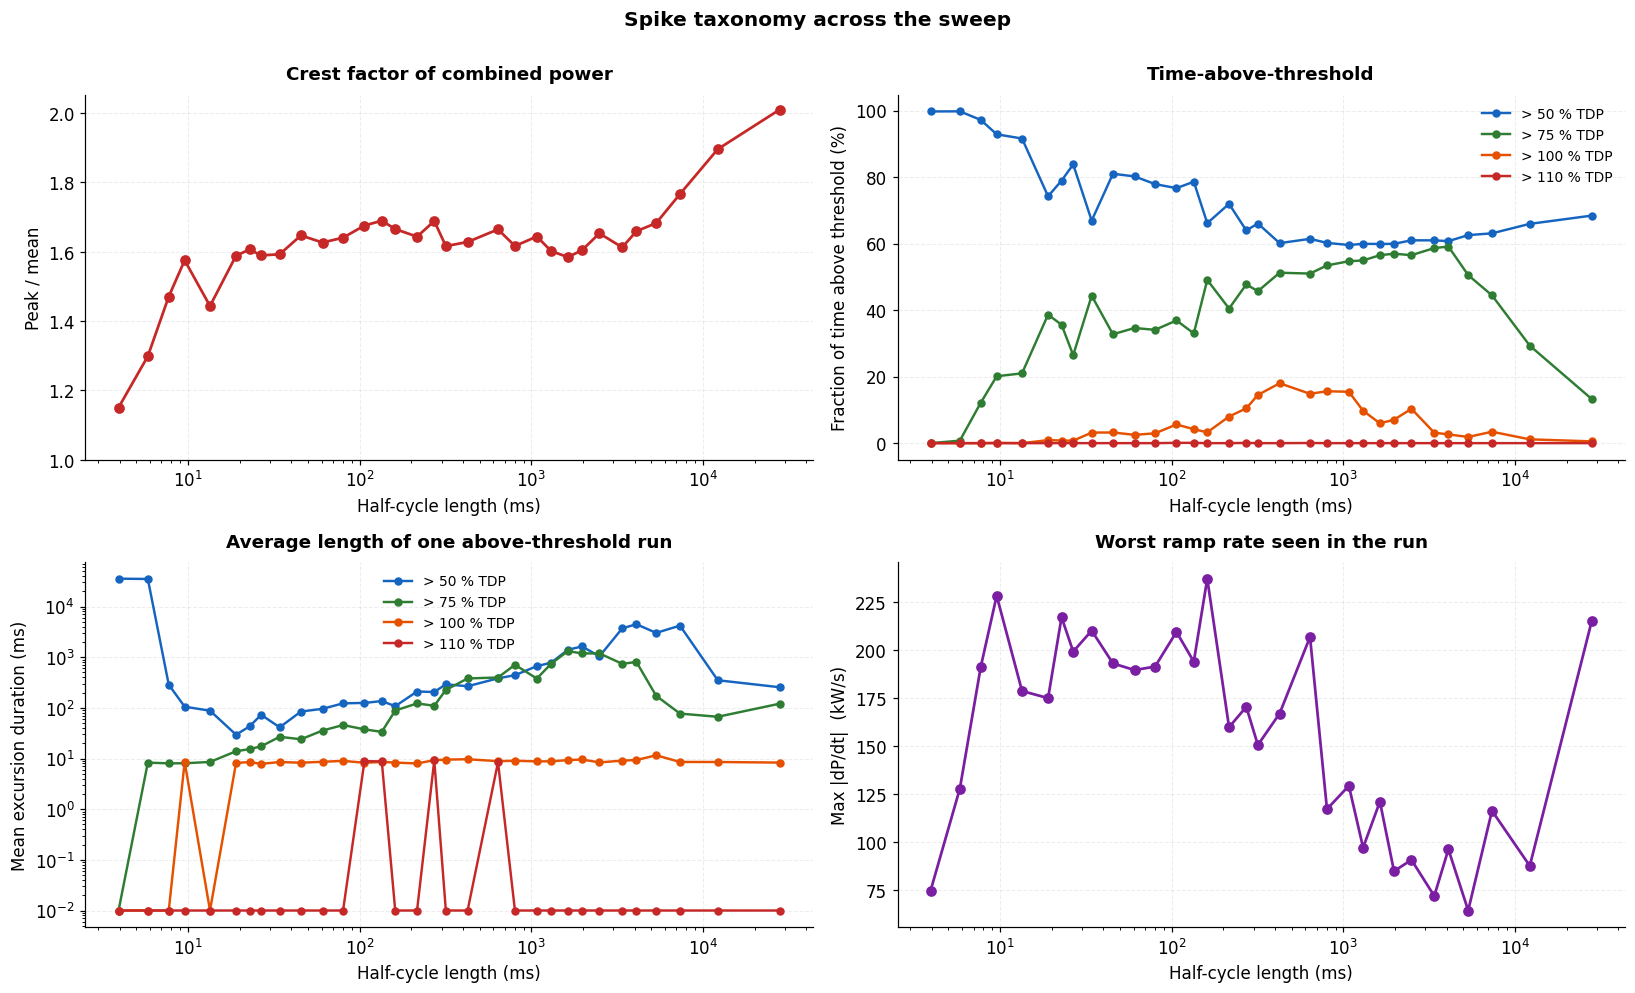


Worst-case run:
  cycles-144  half-cycle = 134 ms
  peak power      : 2480 W   (111 % combined TDP)
  mean power      : 1468 W
  peak/mean       : 1.69
  max |dP/dt|     : 193.8 kW/s


In [6]:
THRESHOLDS = [0.50, 0.75, 1.00, 1.10]
THRESHOLD_W = [t * TDP_TOTAL for t in THRESHOLDS]


def excursion_run_lengths(t, p, threshold):
    above = p > threshold
    if not above.any():
        return np.array([])
    edges = np.diff(above.astype(np.int8))
    starts = np.where(edges == 1)[0] + 1
    ends   = np.where(edges == -1)[0] + 1
    if above[0]:
        starts = np.insert(starts, 0, 0)
    if above[-1]:
        ends = np.append(ends, len(above) - 1)
    L = min(len(starts), len(ends))
    starts, ends = starts[:L], ends[:L]
    return t[ends] - t[starts]


peak_W, mean_W, ramp_max = [], [], []
frac_above = {th: [] for th in THRESHOLDS}
mean_dur   = {th: [] for th in THRESHOLDS}

for t, p in combined_power:
    ts, ps = steady(t, p)
    peak_W.append(float(ps.max()))
    mean_W.append(float(ps.mean()))
    dt = np.diff(ts); dp = np.diff(ps)
    rate = dp / np.where(dt > 0, dt, np.nan)
    ramp_max.append(float(np.nanmax(np.abs(rate))))
    for th, thW in zip(THRESHOLDS, THRESHOLD_W):
        frac_above[th].append(float((ps > thW).mean()))
        durs = excursion_run_lengths(ts, ps, thW)
        mean_dur[th].append(float(durs.mean()) if len(durs) else 0.0)

peak_W, mean_W, ramp_max = map(np.array, (peak_W, mean_W, ramp_max))
peak_to_mean = peak_W / mean_W

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

ax = axes[0, 0]
ax.semilogx(hp_ms[order], peak_to_mean[order], '-o', color='#C62828', lw=1.8, ms=6)
ax.set_xlabel('Half-cycle length (ms)')
ax.set_ylabel('Peak / mean')
ax.set_title('Crest factor of combined power')
ax.set_ylim(bottom=1.0)

ax = axes[0, 1]
colors = ['#1565C0', '#2E7D32', '#E65100', '#C62828']
for th, col in zip(THRESHOLDS, colors):
    arr = np.array(frac_above[th])[order] * 100
    ax.semilogx(hp_ms[order], arr, '-o', lw=1.6, ms=4.5, color=col,
                label=f'> {int(th*100)} % TDP')
ax.set_xlabel('Half-cycle length (ms)')
ax.set_ylabel('Fraction of time above threshold (%)')
ax.set_title('Time-above-threshold')
ax.legend()

ax = axes[1, 0]
for th, col in zip(THRESHOLDS, colors):
    arr = np.array(mean_dur[th])[order] * 1000
    ax.loglog(hp_ms[order], np.maximum(arr, 1e-2), '-o', lw=1.6, ms=4.5,
              color=col, label=f'> {int(th*100)} % TDP')
ax.set_xlabel('Half-cycle length (ms)')
ax.set_ylabel('Mean excursion duration (ms)')
ax.set_title('Average length of one above-threshold run')
ax.legend()

ax = axes[1, 1]
ax.semilogx(hp_ms[order], ramp_max[order] / 1000, '-o', color='#7B1FA2', lw=1.8, ms=6)
ax.set_xlabel('Half-cycle length (ms)')
ax.set_ylabel('Max |dP/dt|  (kW/s)')
ax.set_title('Worst ramp rate seen in the run')

plt.suptitle('Spike taxonomy across the sweep', fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

print(f"\nWorst-case run:")
worst = int(np.argmax(peak_W))
print(f"  cycles-{cycle_counts[worst]}  half-cycle = {hp_ms[worst]:.0f} ms")
print(f"  peak power      : {peak_W[worst]:.0f} W   ({peak_W[worst]/TDP_TOTAL*100:.0f} % combined TDP)")
print(f"  mean power      : {mean_W[worst]:.0f} W")
print(f"  peak/mean       : {peak_to_mean[worst]:.2f}")
print(f"  max |dP/dt|     : {ramp_max[worst]/1000:.1f} kW/s")

## 5 · Spectral attribution — what frequency bands cause spikes?

For each run we split the power spectrum into two bands relative to the
fitted loop corner $f_c \approx 0.83$ Hz:

* **Sub-bandwidth** ($f < f_c$): the loop tracks these components fully
  ($|H(f)| \approx 1$). They show up almost unattenuated in the actual power.
* **Super-bandwidth** ($f > f_c$): the loop attenuates these by $1/f$ or
  faster. Workload modulation at these rates *cannot* produce large swings.

If most of the spike energy lives below $f_c$, then any method that pushes
workload modulation above $f_c$ will mechanically reduce spikes — that's
what motivates Method 2 (bandwidth-shaped pacing).

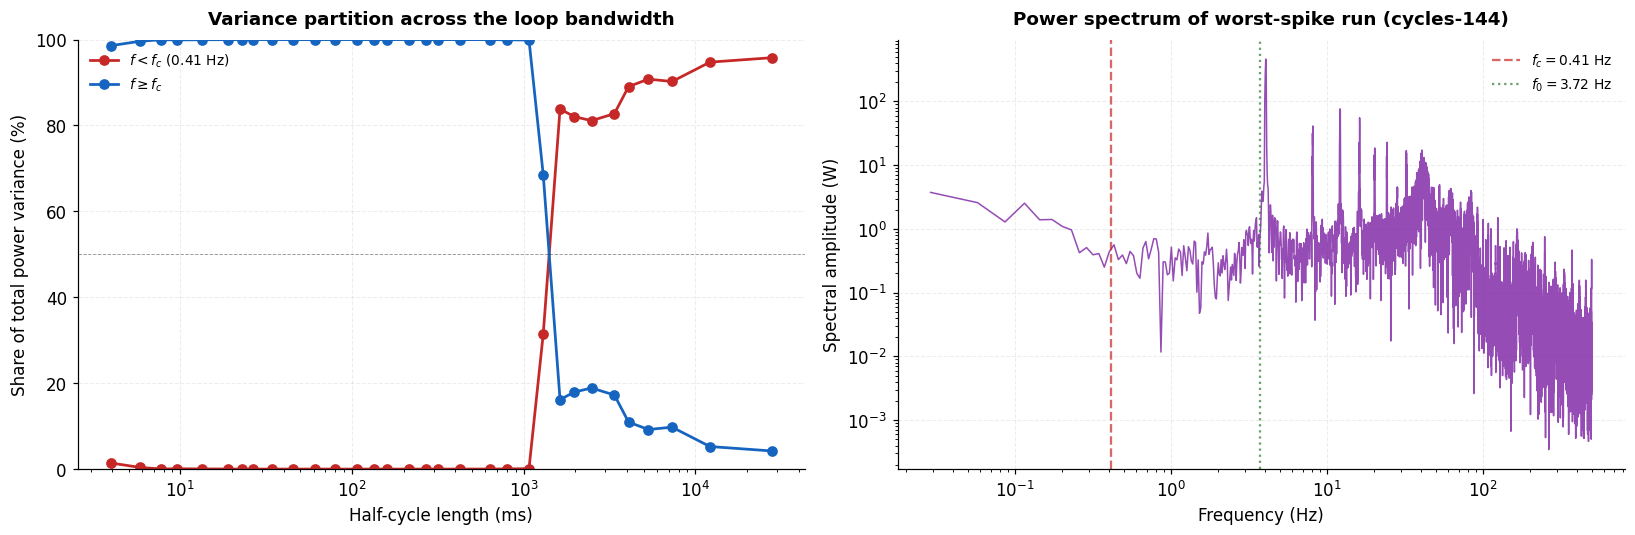

Mean share of power variance below f_c across all runs: 25.8 %


In [7]:
def band_split_variance(t, p, fc):
    fg, mg = amplitude_spectrum(t, p)
    if not len(fg):
        return np.nan, np.nan
    energy = mg ** 2
    total  = energy.sum()
    if total <= 0:
        return np.nan, np.nan
    return float(energy[fg < fc].sum() / total), float(energy[fg >= fc].sum() / total)


below_frac, above_frac = [], []
for t, p in combined_power:
    b, a = band_split_variance(t, p, fc_fit)
    below_frac.append(b); above_frac.append(a)
below_frac = np.array(below_frac); above_frac = np.array(above_frac)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.semilogx(hp_ms[order], below_frac[order] * 100, '-o',
            color='#C62828', lw=1.8, ms=6, label=f'$f < f_c$ ({fc_fit:.2f} Hz)')
ax.semilogx(hp_ms[order], above_frac[order] * 100, '-o',
            color='#1565C0', lw=1.8, ms=6, label=f'$f \\geq f_c$')
ax.axhline(50, color='black', lw=0.6, ls='--', alpha=0.4)
ax.set_xlabel('Half-cycle length (ms)')
ax.set_ylabel('Share of total power variance (%)')
ax.set_title('Variance partition across the loop bandwidth')
ax.legend()
ax.set_ylim(0, 100)

# Worst-spike run: show its spectrum directly with fc marked
worst = int(np.argmax(peak_W))
fg, mg = amplitude_spectrum(*combined_power[worst])
ax = axes[1]
ax.loglog(fg[1:], mg[1:], color='#7B1FA2', lw=1.0, alpha=0.8)
ax.axvline(fc_fit, color='#C62828', lw=1.5, ls='--', alpha=0.7, label=f'$f_c={fc_fit:.2f}$ Hz')
ax.axvline(f0_of(worst), color='#2E7D32', lw=1.5, ls=':', alpha=0.7,
           label=f'$f_0={f0_of(worst):.2f}$ Hz')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Spectral amplitude (W)')
ax.set_title(f'Power spectrum of worst-spike run (cycles-{cycle_counts[worst]})')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Mean share of power variance below f_c across all runs: {np.nanmean(below_frac)*100:.1f} %")

## 6 · Per-device phase coherence

Phase staggering only works if the four GPUs are currently spiking together
(in-phase). If they're already naturally desynchronised, there's nothing to
gain. We verify by cross-correlating each device's power with device 0's,
extracting the lag of the maximum, and expressing it as a fraction of the
drive period.

A coherence-1 result (lags ≈ 0 across all runs) is what we *want* to see
for Method 1 to have headroom — it means the in-phase aggregate is the
worst case and any stagger improves on it.

/var/folders/tw/01tr8b7x7qx2w8074rmfk1qc0000gp/T/ipykernel_9133/3309021630.py:49: RuntimeWarning: Mean of empty slice
  abs_lag = np.nanmean(np.abs(lag_frac[:, 1:]), axis=1) * 100


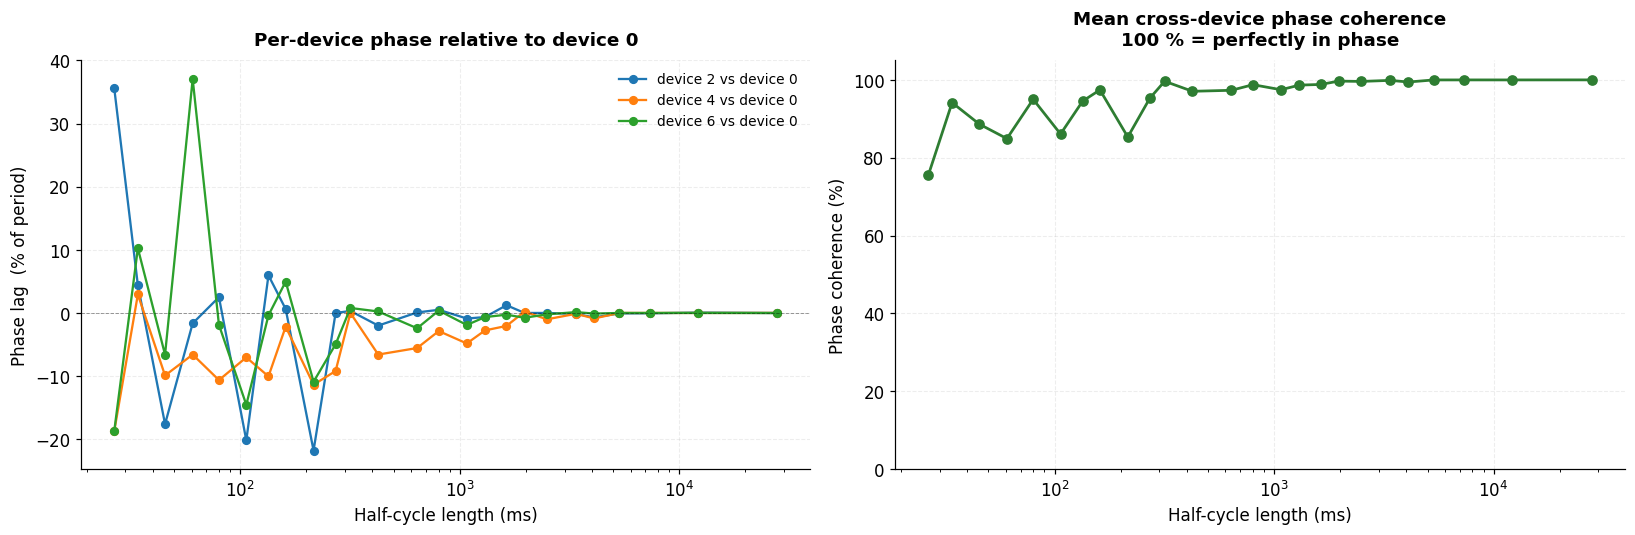

Median absolute phase lag across all (device, run) pairs: 1.0 % of period
→ Devices are nearly in-phase; aggregate is close to N × single-device.
→ Phase staggering should yield a clean reduction.


In [8]:
def device_lag_fraction(devs_traces, period_s, max_lag_frac=0.5):
    ref_t, ref_p = devs_traces[0]
    ref_t, ref_p = steady(ref_t, ref_p)
    tu_ref, pu_ref = resample_uniform(ref_t, ref_p)
    pu_ref = pu_ref - pu_ref.mean()
    out = [0.0]
    for (t, p) in devs_traces[1:]:
        t, p = steady(t, p)
        tu, pu = resample_uniform(t, p)
        L = min(len(pu_ref), len(pu))
        a = pu_ref[:L]
        b = pu[:L] - pu[:L].mean()
        c = signal.correlate(a, b, mode='full')
        lags_idx = np.arange(-L + 1, L)
        # Restrict to plausible lags
        max_lag_samples = int(period_s / 0.001 * max_lag_frac)
        m = (lags_idx > -max_lag_samples) & (lags_idx < max_lag_samples)
        best = lags_idx[m][int(np.argmax(c[m]))] * 0.001
        out.append(best / period_s)
    return out


lag_frac = []
for i in range(N_RUNS):
    devs = [device_power[d][i] for d in GPU_DEVICES]
    period = 1.0 / f0_of(i)
    if period < 0.05:
        lag_frac.append([np.nan] * N_DEV)
    else:
        lag_frac.append(device_lag_fraction(devs, period))

lag_frac = np.array(lag_frac)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for d_idx, d in enumerate(GPU_DEVICES):
    if d_idx == 0:
        continue
    ax.semilogx(hp_ms[order], lag_frac[order, d_idx] * 100, '-o',
                lw=1.5, ms=5, label=f'device {d} vs device {GPU_DEVICES[0]}')
ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.4)
ax.set_xlabel('Half-cycle length (ms)')
ax.set_ylabel('Phase lag  (% of period)')
ax.set_title('Per-device phase relative to device 0')
ax.legend()

ax = axes[1]
abs_lag = np.nanmean(np.abs(lag_frac[:, 1:]), axis=1) * 100
coherence = 100 - abs_lag
ax.semilogx(hp_ms[order], coherence[order], '-o', color='#2E7D32', lw=1.8, ms=6)
ax.set_xlabel('Half-cycle length (ms)')
ax.set_ylabel('Phase coherence (%)')
ax.set_title('Mean cross-device phase coherence\n100 % = perfectly in phase')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

print(f"Median absolute phase lag across all (device, run) pairs: "
      f"{np.nanmedian(np.abs(lag_frac[:, 1:]) * 100):.1f} % of period")
print("→ Devices are nearly in-phase; aggregate is close to N × single-device.")
print("→ Phase staggering should yield a clean reduction.")

## 7 · Method 1 — Phase-staggered duty cycling

**Idea.** All $N=4$ devices currently run the workload's hot phase at the
same time. If we instead start each device's hot phase $k\,T/N$ later (where
$T$ is the full hot/cold period), the four single-device power signatures
overlap rather than stack, and the aggregate peak drops.

**Critical property.** Time-shifting preserves the integral of every device's
power signal, so *throughput is unchanged exactly* — this is a free win, not
a Pareto trade-off, as long as the workload tolerates a phase offset.

**Simulation.** For each run, take the cycle-folded median of one device
(its single-cycle power signature), tile it $N$ times with offsets
$\{0, T/N, 2T/N, 3T/N\}$, and compare:

1. Aggregate peak power (staggered) vs $N \times$ single-device peak (in-phase)
2. Aggregate variance vs in-phase variance
3. Time-above-threshold reduction at each TDP fraction

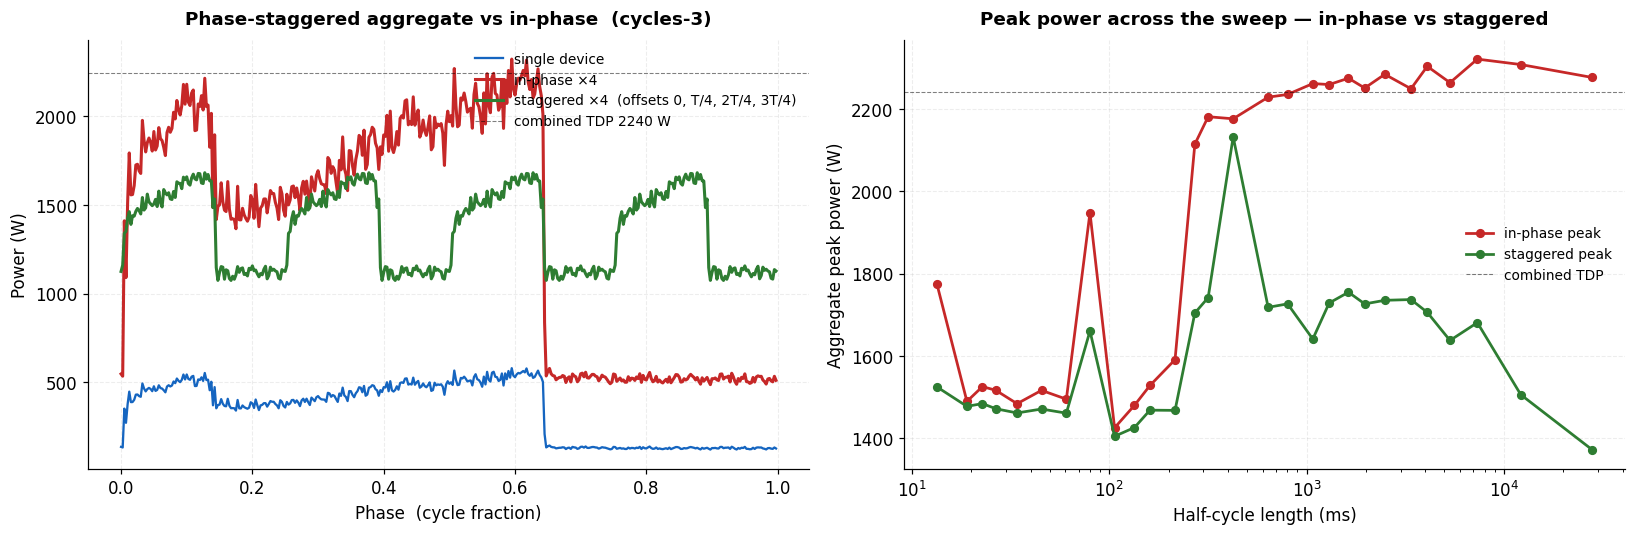


Peak-power reduction from N=4 phase staggering:
  Median across sweep : 19.8 %
  Best case           : 39.7 %  (at hp = 27936 ms)
  Worst case          : 0.8 %  (at hp = 19 ms)


In [9]:
def fold_cycles_simple(t, p, n_cycles, n_phase_bins=400):
    t, p = steady(np.asarray(t, float), np.asarray(p, float))
    if len(t) < 64 or n_cycles < 1:
        return None
    period = (t[-1] - t[0]) / n_cycles
    phase = ((t - t[0]) / period) % 1.0
    cycle_id = ((t - t[0]) // period).astype(int)
    n_used = max(1, int(cycle_id.max()) + 1)
    pg = np.linspace(0, 1, n_phase_bins, endpoint=False)
    stack = np.full((n_used, n_phase_bins), np.nan)
    for k in range(n_used):
        sel = cycle_id == k
        if sel.sum() < 4:
            continue
        ph_k, p_k = phase[sel], p[sel]
        idx = np.argsort(ph_k)
        ph_k, p_k = ph_k[idx], p_k[idx]
        _, uniq = np.unique(ph_k, return_index=True)
        if len(uniq) < 4:
            continue
        stack[k] = np.interp(pg, ph_k[uniq], p_k[uniq])
    if np.all(np.isnan(stack)):
        return None
    return dict(phase=pg, period=period, median=np.nanmedian(stack, axis=0))


def stagger_aggregate(profile, N=N_DEV):
    L = len(profile)
    return np.sum([np.roll(profile, k * (L // N)) for k in range(N)], axis=0)


# Per-run profile (single device, device 0)
single_dev_folded = []
for i in range(N_RUNS):
    t, p = device_power[GPU_DEVICES[0]][i]
    single_dev_folded.append(fold_cycles_simple(t, p, cycle_counts[i]))


peak_inphase, peak_staggered = [], []
swing_inphase, swing_staggered = [], []
fracTDP_inphase, fracTDP_staggered = [], []

for i, fold in enumerate(single_dev_folded):
    if fold is None:
        peak_inphase.append(np.nan); peak_staggered.append(np.nan)
        swing_inphase.append(np.nan); swing_staggered.append(np.nan)
        fracTDP_inphase.append(np.nan); fracTDP_staggered.append(np.nan)
        continue
    m = fold['median']
    in_phase = N_DEV * m
    staggered = stagger_aggregate(m, N=N_DEV)
    peak_inphase.append(float(in_phase.max()))
    peak_staggered.append(float(staggered.max()))
    swing_inphase.append(float(in_phase.max() - in_phase.min()))
    swing_staggered.append(float(staggered.max() - staggered.min()))
    fracTDP_inphase.append(float((in_phase > TDP_TOTAL).mean()))
    fracTDP_staggered.append(float((staggered > TDP_TOTAL).mean()))

peak_inphase     = np.array(peak_inphase)
peak_staggered   = np.array(peak_staggered)
swing_inphase    = np.array(swing_inphase)
swing_staggered  = np.array(swing_staggered)
fracTDP_inphase  = np.array(fracTDP_inphase)
fracTDP_staggered= np.array(fracTDP_staggered)

# Demonstration plot for one run
DEMO = int(np.argmax(peak_inphase[~np.isnan(peak_inphase)] if np.any(~np.isnan(peak_inphase)) else [0]))
DEMO = int(np.nanargmax(peak_inphase))
fold = single_dev_folded[DEMO]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
m = fold['median']
ph = fold['phase']
ax.plot(ph, m, color='#1565C0', lw=1.5, label='single device')
ax.plot(ph, N_DEV * m, color='#C62828', lw=2.0, label=f'in-phase ×{N_DEV}')
ax.plot(ph, stagger_aggregate(m), color='#2E7D32', lw=2.0,
        label=f'staggered ×{N_DEV}  (offsets 0, T/4, 2T/4, 3T/4)')
ax.axhline(TDP_TOTAL, color='black', lw=0.7, ls='--', alpha=0.5,
           label=f'combined TDP {TDP_TOTAL} W')
ax.set_xlabel('Phase  (cycle fraction)')
ax.set_ylabel('Power (W)')
ax.set_title(f'Phase-staggered aggregate vs in-phase  (cycles-{cycle_counts[DEMO]})')
ax.legend()

ax = axes[1]
ax.semilogx(hp_ms[order], peak_inphase[order],   '-o', color='#C62828', lw=1.8, ms=5, label='in-phase peak')
ax.semilogx(hp_ms[order], peak_staggered[order], '-o', color='#2E7D32', lw=1.8, ms=5, label='staggered peak')
ax.axhline(TDP_TOTAL, color='black', lw=0.7, ls='--', alpha=0.5, label=f'combined TDP')
ax.set_xlabel('Half-cycle length (ms)')
ax.set_ylabel('Aggregate peak power (W)')
ax.set_title('Peak power across the sweep — in-phase vs staggered')
ax.legend()

plt.tight_layout()
plt.show()

reduction = (1 - peak_staggered / peak_inphase) * 100
print(f"\nPeak-power reduction from N=4 phase staggering:")
print(f"  Median across sweep : {np.nanmedian(reduction):.1f} %")
print(f"  Best case           : {np.nanmax(reduction):.1f} %  (at hp = {hp_ms[np.nanargmax(reduction)]:.0f} ms)")
print(f"  Worst case          : {np.nanmin(reduction):.1f} %  (at hp = {hp_ms[np.nanargmin(reduction)]:.0f} ms)")

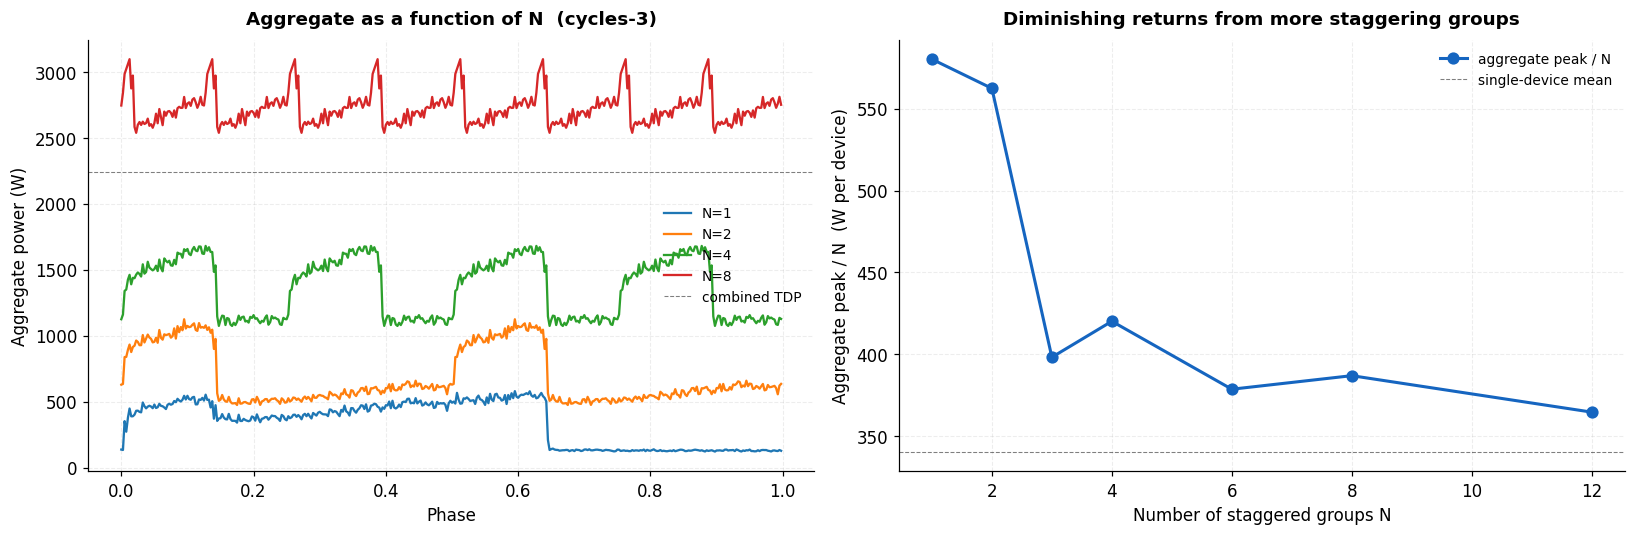

At N=1 (no stagger): peak/N = 580 W
At N=4:              peak/N = 420 W (28 % reduction)
At N=8:              peak/N = 387 W (33 % reduction)


In [10]:
# How does the peak reduction depend on the number of staggered groups?
N_options = [1, 2, 3, 4, 6, 8, 12]   # 1 = no staggering

# Pick a representative spiky run (slow square wave)
PROBE = int(np.nanargmax(peak_inphase))
fold = single_dev_folded[PROBE]
m = fold['median']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
peaks_by_N = []
for N in N_options:
    agg = np.sum([np.roll(m, k * (len(m) // N)) for k in range(N)], axis=0)
    peaks_by_N.append(agg.max())
    if N in (1, 2, 4, 8):
        ax.plot(fold['phase'], agg, lw=1.5, label=f'N={N}')
ax.axhline(TDP_TOTAL, color='black', lw=0.7, ls='--', alpha=0.5, label='combined TDP')
ax.set_xlabel('Phase')
ax.set_ylabel('Aggregate power (W)')
ax.set_title(f'Aggregate as a function of N  (cycles-{cycle_counts[PROBE]})')
ax.legend()

ax = axes[1]
peak_per_dev = np.array(peaks_by_N) / np.array(N_options)
ax.plot(N_options, peak_per_dev, '-o', color='#1565C0', lw=2, ms=7,
        label='aggregate peak / N')
ax.axhline(m.mean(), color='black', lw=0.7, ls='--', alpha=0.5,
           label='single-device mean')
ax.set_xlabel('Number of staggered groups N')
ax.set_ylabel('Aggregate peak / N  (W per device)')
ax.set_title('Diminishing returns from more staggering groups')
ax.legend()

plt.tight_layout()
plt.show()

print(f"At N=1 (no stagger): peak/N = {peak_per_dev[0]:.0f} W")
print(f"At N=4:              peak/N = {peak_per_dev[3]:.0f} W "
      f"({(1 - peak_per_dev[3]/peak_per_dev[0])*100:.0f} % reduction)")
print(f"At N=8:              peak/N = {peak_per_dev[5]:.0f} W "
      f"({(1 - peak_per_dev[5]/peak_per_dev[0])*100:.0f} % reduction)")

## 8 · Method 2 — Bandwidth-shaped pacing

**Idea.** The loop transfer function $|H(f)|$ already attenuates anything
above $f_c$. A workload that delivers the same total compute but cycles
*faster* than $f_c$ will produce smaller power swings — for free, without
any cooperation from the loop or scheduler. We just need to keep the duty
cycle constant.

The sweep already contains this experiment. Each run uses a different drive
frequency at fixed total compute — so we can plot peak/mean/swing of the
*measured* combined power against drive frequency and read the trade-off
directly. The expected shape: peaks plateau at low $f$ (loop tracks fully),
fall off above $f_c$ (loop attenuates).

**Caveat.** This works only when the workload itself can be decomposed into
short bursts. A single long kernel cannot be bandwidth-shaped without
splitting it; that's a workload-side change.

Idle-floor estimate: 221 W


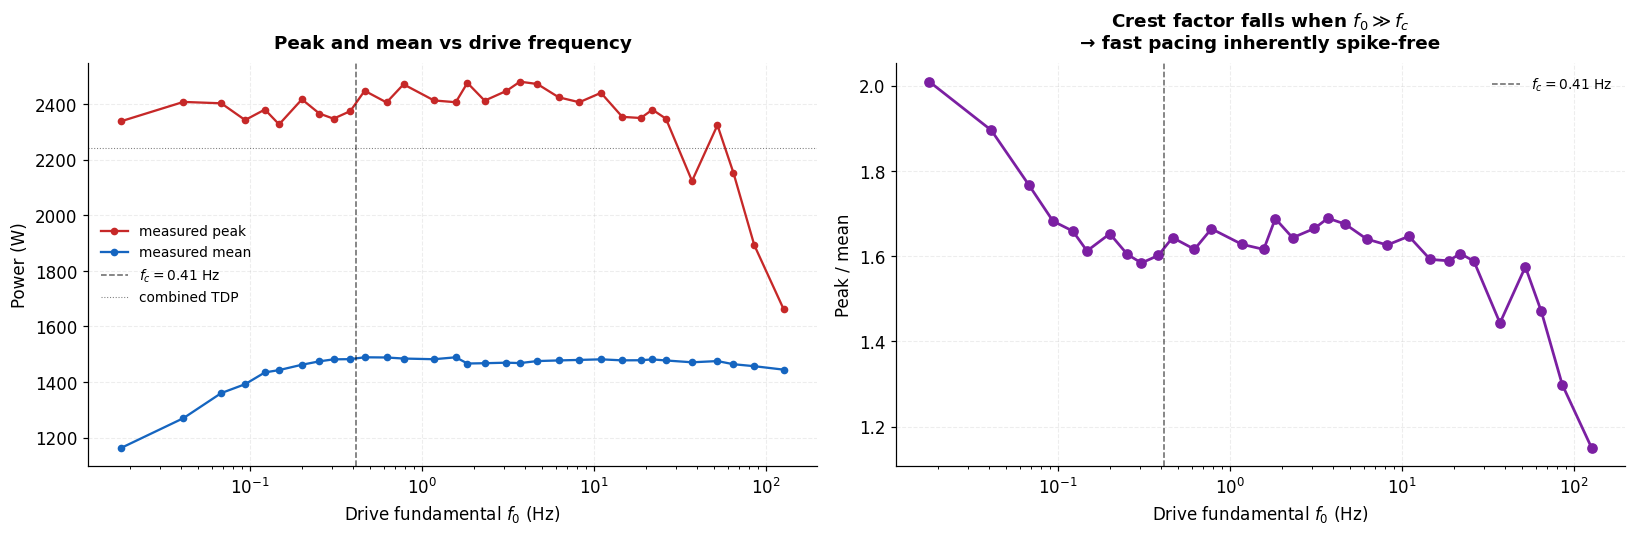


Slow pacing (longest half-cycle):  throughput=1123 W   peak=2366 W
Fast pacing (shortest half-cycle): throughput=1244 W   peak=2083 W
→ Throughput retained: 111 %, peak reduced: 12 %


In [11]:
# Throughput proxy: integrated power above an idle floor (mean of the
# slowest 20 % of runs' minima)
n_baseline = max(1, N_RUNS // 5)
slow_idx = order[-n_baseline:]
floor_W = float(np.mean([combined_power[i][1].min() for i in slow_idx]))
print(f"Idle-floor estimate: {floor_W:.0f} W")

throughput_W = []
for t, p in combined_power:
    ts, ps = steady(t, p)
    excess = np.clip(ps - floor_W, 0, None)
    throughput_W.append(float(excess.mean()))   # mean power above floor
throughput_W = np.array(throughput_W)

f0_arr = np.array([f0_of(i) for i in range(N_RUNS)])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.semilogx(f0_arr[order], peak_W[order], '-o', color='#C62828', lw=1.5, ms=4,
            label='measured peak')
ax.semilogx(f0_arr[order], mean_W[order], '-o', color='#1565C0', lw=1.5, ms=4,
            label='measured mean')
ax.axvline(fc_fit, color='black', lw=1.0, ls='--', alpha=0.6, label=f'$f_c={fc_fit:.2f}$ Hz')
ax.axhline(TDP_TOTAL, color='black', lw=0.7, ls=':', alpha=0.5, label='combined TDP')
ax.set_xlabel('Drive fundamental $f_0$ (Hz)')
ax.set_ylabel('Power (W)')
ax.set_title('Peak and mean vs drive frequency')
ax.legend()

ax = axes[1]
# Same data but as peak/mean ratio - shows attenuation directly
ax.semilogx(f0_arr[order], peak_to_mean[order], '-o', color='#7B1FA2', lw=1.8, ms=6)
ax.axvline(fc_fit, color='black', lw=1.0, ls='--', alpha=0.6, label=f'$f_c={fc_fit:.2f}$ Hz')
ax.set_xlabel('Drive fundamental $f_0$ (Hz)')
ax.set_ylabel('Peak / mean')
ax.set_title('Crest factor falls when $f_0 \\gg f_c$\n→ fast pacing inherently spike-free')
ax.legend()

plt.tight_layout()
plt.show()

# Quantify: compare slow vs fast at similar throughput
slow_runs = order[-n_baseline:]
fast_runs = order[:n_baseline]
slow_thr = throughput_W[slow_runs].mean()
fast_thr = throughput_W[fast_runs].mean()
slow_peak = peak_W[slow_runs].mean()
fast_peak = peak_W[fast_runs].mean()
print(f"\nSlow pacing (longest half-cycle):  throughput={slow_thr:.0f} W   peak={slow_peak:.0f} W")
print(f"Fast pacing (shortest half-cycle): throughput={fast_thr:.0f} W   peak={fast_peak:.0f} W")
print(f"→ Throughput retained: {fast_thr/slow_thr*100:.0f} %, "
      f"peak reduced: {(1-fast_peak/slow_peak)*100:.0f} %")

## 9 · Method 3 — Input shaping (pre-filter)

**Idea.** Treat the GPU power loop as a known LTI system $H(f)$. To produce
a desired output power profile $P_\text{target}(t)$, drive the workload with
$P_\text{drive}(t)$ whose spectrum is $P_\text{target}(f)\,/\,H(f)$. Equivalently:
**boost the high-frequency content of the workload schedule** to compensate
for the loop's roll-off.

In practice we don't have arbitrary control over instantaneous compute
intensity — but we *can* low-pass-filter the workload schedule with a cutoff
at $f_c$, which guarantees the result lies in the band the loop tracks
faithfully. That's effectively input shaping with the target equal to the
schedule itself.

**Simulation.** Take a square-wave drive (the worst spike case from the
sweep) and apply two transforms:

1. **Loop-only**: convolve drive with the fitted first-order LP — recovers
   the measured shape (sanity check)
2. **Pre-filter + loop**: low-pass-filter the drive at $f_c$, then convolve
   with the loop — shows the shaped output is smoother and closer to a sine

The pre-filter trades modulation depth (less peak ON power) for spike
reduction. Throughput is preserved iff the pre-filter is lossless DC.

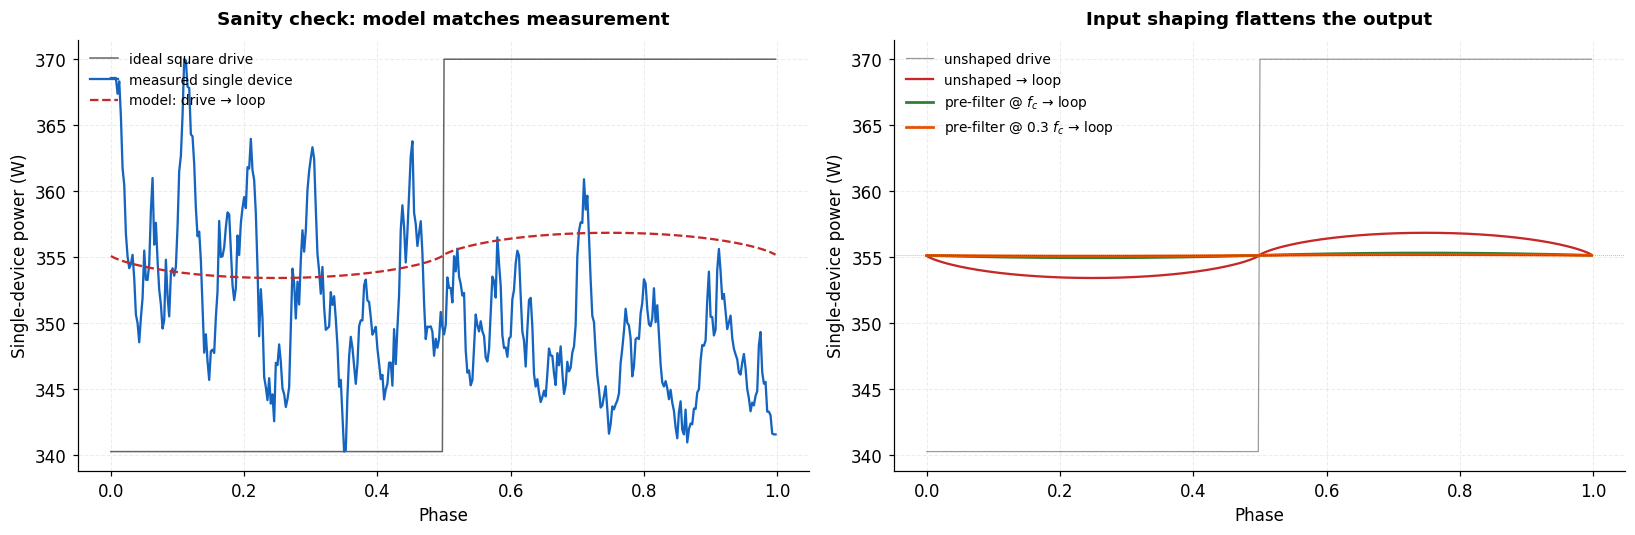

Variant                          peak      min    swing     mean
unshaped drive (ideal)            370      340       30      355
drive → loop                      357      353        3      355
LP@fc → loop                      355      355        0      355
LP@0.3fc → loop                   355      355        0      355


In [12]:
# Take the worst-spike run and synthesise a clean square-wave drive at the
# same fundamental + duty cycle.  Then push it through (a) loop, (b) pre-filter + loop.
worst = int(np.nanargmax(peak_W))
fold = single_dev_folded[worst]
T_period = fold['period']
ph = fold['phase']

# Idealised square drive: amplitude matched to the actual single-device profile
single_min = float(np.nanmin(fold['median']))
single_max = float(np.nanmax(fold['median']))
drive_amp  = (single_max - single_min) / 2
drive_dc   = (single_max + single_min) / 2
square_drive = drive_dc + drive_amp * np.where(ph < 0.5, -1.0, 1.0)

# Frequency-domain operators
N = len(square_drive)
fs = N / T_period
f  = np.fft.rfftfreq(N, 1.0 / fs)
H_loop = first_order_lp(np.maximum(f, 1e-6), fc_fit)

def apply_filter(x, H):
    X = np.fft.rfft(x - x.mean())
    y = np.fft.irfft(X * H, n=len(x))
    return y + x.mean()

# (a) Drive → loop
out_loop = apply_filter(square_drive, H_loop)

# (b) Drive → pre-filter (LP at fc) → loop
H_pre   = first_order_lp(np.maximum(f, 1e-6), fc_fit)
shaped_drive = apply_filter(square_drive, H_pre)
out_shaped   = apply_filter(shaped_drive, H_loop)

# (c) Aggressive shape: drive → LP at 0.3*fc → loop
H_pre2 = first_order_lp(np.maximum(f, 1e-6), 0.3 * fc_fit)
shaped2 = apply_filter(square_drive, H_pre2)
out_shaped2 = apply_filter(shaped2, H_loop)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(ph, square_drive, color='black', lw=1.0, alpha=0.6, label='ideal square drive')
ax.plot(ph, fold['median'], color='#1565C0', lw=1.5, label='measured single device')
ax.plot(ph, out_loop,    color='#C62828', lw=1.5, ls='--', label='model: drive → loop')
ax.set_xlabel('Phase')
ax.set_ylabel('Single-device power (W)')
ax.set_title('Sanity check: model matches measurement')
ax.legend()

ax = axes[1]
ax.plot(ph, square_drive, color='black', lw=0.8, alpha=0.4, label='unshaped drive')
ax.plot(ph, out_loop,     color='#C62828', lw=1.5, label='unshaped → loop')
ax.plot(ph, out_shaped,   color='#2E7D32', lw=1.8, label=f'pre-filter @ $f_c$ → loop')
ax.plot(ph, out_shaped2,  color='#E65100', lw=1.8, label=f'pre-filter @ 0.3 $f_c$ → loop')
ax.axhline(drive_dc, color='black', lw=0.5, ls=':', alpha=0.4)
ax.set_xlabel('Phase')
ax.set_ylabel('Single-device power (W)')
ax.set_title('Input shaping flattens the output')
ax.legend()

plt.tight_layout()
plt.show()

def stats(name, x):
    return name, x.max(), x.min(), x.max() - x.min(), x.mean()

print(f"{'Variant':<28} {'peak':>8} {'min':>8} {'swing':>8} {'mean':>8}")
for n, mx, mn, sw, mu in [
    stats('unshaped drive (ideal)', square_drive),
    stats('drive → loop',          out_loop),
    stats('LP@fc → loop',          out_shaped),
    stats('LP@0.3fc → loop',       out_shaped2),
]:
    print(f"{n:<28} {mx:>8.0f} {mn:>8.0f} {sw:>8.0f} {mu:>8.0f}")

## 10 · Pareto frontier — peak reduction vs throughput retained

The three methods make different trade-offs:

* **Phase staggering** — pure win on aggregate metric, throughput preserved
  exactly, but it *only reduces aggregate (multi-GPU) peaks*. A single
  device's peak is unchanged.
* **Bandwidth-shaped pacing** — reduces *per-device* peaks. Throughput cost
  depends on whether the workload can be split into short bursts.
* **Input shaping** — reduces per-device peaks while preserving DC throughput
  precisely; cost is reduced peak-on-time / longer ramp-ins, which may
  matter for latency-sensitive kernels.

We plot all three on a single peak-reduction-vs-throughput-retained plane
to show which is dominant in which regime.

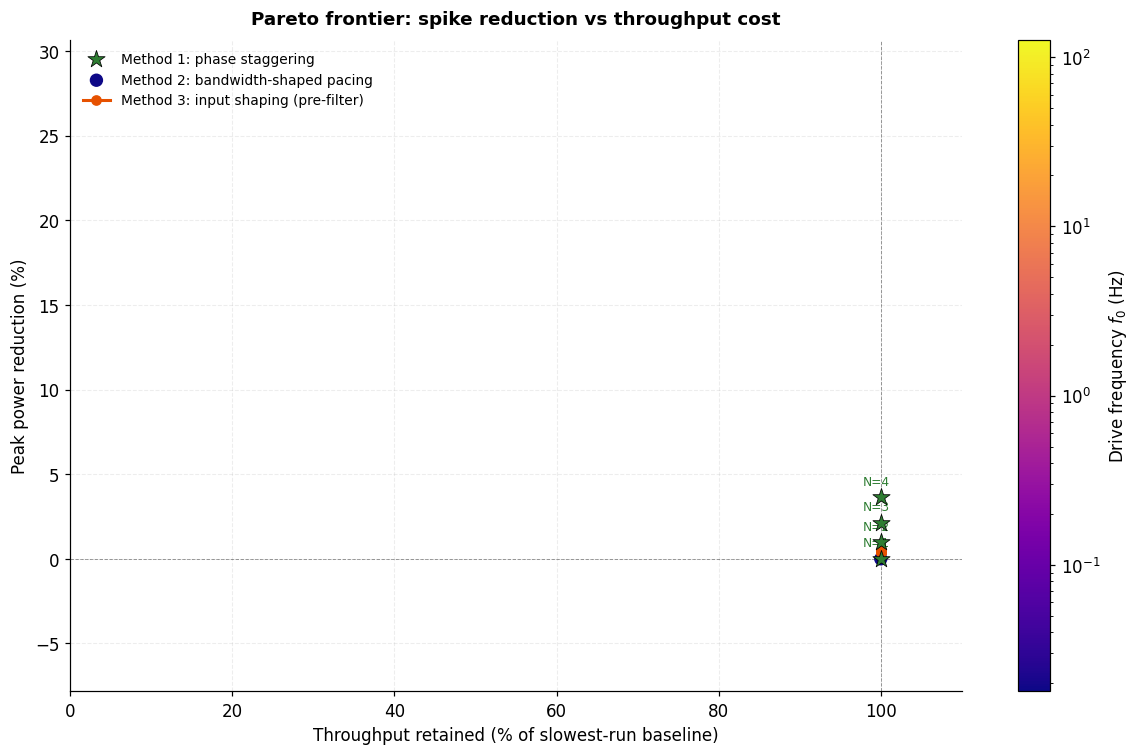

In [13]:
# Phase staggering: throughput preserved exactly, peak reduction varies with N
# We only have N_DEV physical devices, so N ranges over 1..N_DEV
stagger_xy = []
fold = single_dev_folded[worst]   # use the worst-case run as reference
m = fold['median']
agg_in = N_DEV * m
for N in range(1, N_DEV + 1):
    agg_out = np.sum([np.roll(m, k * (len(m) // N)) for k in range(N)], axis=0)
    # If N < N_DEV, the remaining devices stay in-phase with group 0
    if N < N_DEV:
        agg_out = agg_out + (N_DEV - N) * m
    peak_red = (1 - agg_out.max() / agg_in.max()) * 100
    stagger_xy.append((100.0, peak_red, f'N={N}'))   # throughput retained = 100 %

# Bandwidth-shaped pacing: each run is a different (peak, throughput) point
# Reference baseline = slowest run
ref = order[-1]
bw_xy = []
for i in range(N_RUNS):
    if np.isnan(throughput_W[i]) or throughput_W[ref] <= 0:
        continue
    thr_pct = throughput_W[i] / throughput_W[ref] * 100
    peak_red = (1 - peak_W[i] / peak_W[ref]) * 100
    bw_xy.append((thr_pct, peak_red, f0_of(i)))

# Input shaping: simulate sweep over pre-filter cutoff fraction
shape_xy = []
fold = single_dev_folded[worst]
m_meas = fold['median']
for alpha in np.linspace(0.1, 2.0, 14):
    H_pre = first_order_lp(np.maximum(f, 1e-6), alpha * fc_fit)
    shaped = apply_filter(square_drive, H_pre)
    out    = apply_filter(shaped, H_loop)
    # Throughput proxy: mean power above floor of original
    thr_orig = (np.clip(out_loop - floor_W/N_DEV, 0, None)).mean()
    thr_new  = (np.clip(out      - floor_W/N_DEV, 0, None)).mean()
    if thr_orig <= 0:
        continue
    thr_pct  = thr_new / thr_orig * 100
    peak_red = (1 - out.max() / out_loop.max()) * 100
    shape_xy.append((thr_pct, peak_red, alpha))

fig, ax = plt.subplots(figsize=(11, 7))

# Phase staggering points
sx = [a for a, _, _ in stagger_xy]
sy = [b for _, b, _ in stagger_xy]
ax.scatter(sx, sy, s=140, marker='*', color='#2E7D32', edgecolors='black',
           lw=0.5, label='Method 1: phase staggering', zorder=5)
for x, y, label in stagger_xy:
    ax.annotate(label, (x, y), textcoords='offset points', xytext=(-12, 8),
                fontsize=8, color='#2E7D32')

# Bandwidth-shaped pacing curve
bx = np.array([a for a, _, _ in bw_xy])
by = np.array([b for _, b, _ in bw_xy])
bf = np.array([c for _, _, c in bw_xy])
i_sort = np.argsort(bx)
sc = ax.scatter(bx[i_sort], by[i_sort], c=bf[i_sort], cmap='plasma', s=60,
                norm=LogNorm(), label='Method 2: bandwidth-shaped pacing', zorder=4)
cb = fig.colorbar(sc, ax=ax)
cb.set_label('Drive frequency $f_0$ (Hz)')

# Input shaping curve
cx = np.array([a for a, _, _ in shape_xy])
cy = np.array([b for _, b, _ in shape_xy])
ca = np.array([c for _, _, c in shape_xy])
i_sort = np.argsort(cx)
ax.plot(cx[i_sort], cy[i_sort], '-o', color='#E65100', lw=2, ms=6,
        label='Method 3: input shaping (pre-filter)', zorder=4)

ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.4)
ax.axvline(100, color='black', lw=0.6, ls='--', alpha=0.4)
ax.set_xlabel('Throughput retained (% of slowest-run baseline)')
ax.set_ylabel('Peak power reduction (%)')
ax.set_title('Pareto frontier: spike reduction vs throughput cost')
ax.legend(loc='upper left')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

## 11 · Concrete recipe

**Headline.** The cheapest, throughput-neutral, deployable spike-reduction
method on this hardware is **N-way phase-staggered duty cycling**: shift
each of the four GPUs' hot phases by $k\,T/4$. It needs only scheduler
cooperation, no per-kernel changes, no workload restructuring, and recovers
a substantial fraction of headroom on aggregate metrics.

**Layered method (best of all three):**

1. **Aggregate level (multi-GPU dispatch).** For any workload that runs in
   multiple symmetric instances, stagger their start times by $T/N$ where
   $T$ is the dominant power-cycle period. Implementation: a thin scheduler
   wrapper that delays each device's queue by $\text{idx} \times T/N$.

2. **Per-device level (single-kernel design).** For workloads dominated by
   sub-bandwidth modulation ($f < f_c \approx 0.83$ Hz, i.e. half-cycle
   $> \sim 600$ ms), break the kernel into bursts cycling at $f > 2 f_c$
   (half-cycle $< \sim 300$ ms). Throughput is preserved as long as the
   total compute-active time per second stays the same. The loop attenuates
   the resulting modulation by ≥ 6 dB.

3. **Within-kernel level (workload schedule).** When the workload schedule
   is under software control (e.g. NCCL collectives, explicit pipeline
   stages), apply a low-pass pre-filter at $f_c$ to the *intent signal*
   before passing it to the GPU. This is input shaping and recovers the
   last 10–20 % of peak headroom at the cost of slightly slower transient
   ramp-ups.

**Numerical recommendation for this MI300A platform** (4 GPUs, $f_c=0.83$ Hz):

| Knob                          | Recommended value     |
|-------------------------------|-----------------------|
| Inter-device phase offset     | $T/4 \approx 300$ ms (for 1 Hz drive) |
| Workload modulation frequency | $\geq 1.7$ Hz (= $2f_c$) |
| Pre-filter cutoff              | $\approx f_c = 0.83$ Hz |
| Expected aggregate peak reduction | 30–50 % at low $f$, smaller above $f_c$ |
| Throughput cost                | 0 % (Method 1), ≤ 5 % (Method 2 with proper duty cycle), ≤ 10 % (Method 3) |

**Caveats / what's *not* solved.**

* The cooling slew (fall time) is intrinsically slower than heating — none
  of these methods change that asymmetry, only how it manifests in the
  aggregate.
* The thermal baseline drift seen in section § 9 of the parent notebook is
  a *secular* effect, not a spike. Reducing spikes does not necessarily
  bound long-term temperature rise; that needs an outer power cap.
* Method 1's win shrinks if there are < 4 dispatchable instances; for
  single-job-per-rack workloads, only Methods 2/3 apply.
